In [1]:
!pip install opencv-python

In [2]:
import cv2
import os

In [4]:
video_path = "/kaggle/input/datasets/sp23bse071/cvforvideos/10297621-sd_640_360_30fps.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error opening video")

In [5]:
fps = cap.get(cv2.CAP_PROP_FPS)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Width:", width)
print("Height:", height)
print("Total Frames:", total_frames)

FPS: 29.97002997002997
Width: 640
Height: 360
Total Frames: 624


In [6]:
output_path = "/kaggle/working/processed_video1.mp4"

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height),
    False
)

In [7]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur,100,200)

    out.write(edges)

cap.release()
out.release()

print("Video Saved")

Video Saved


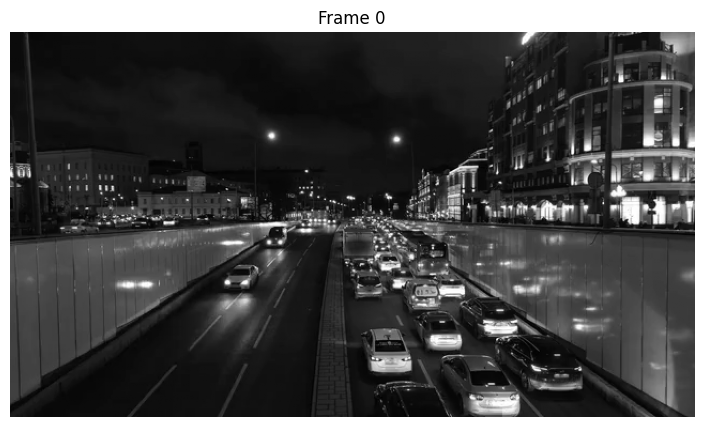

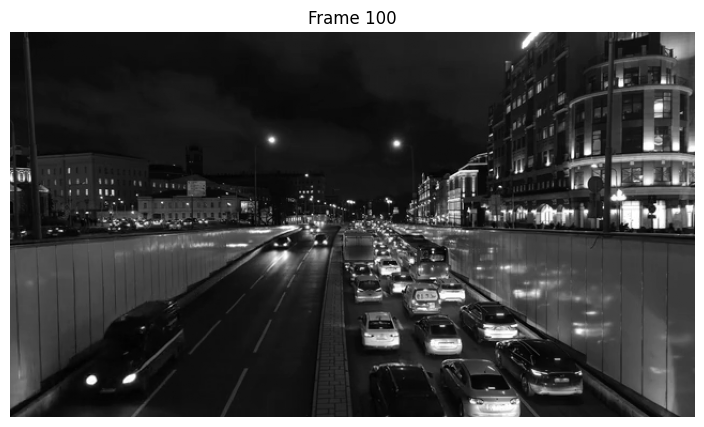

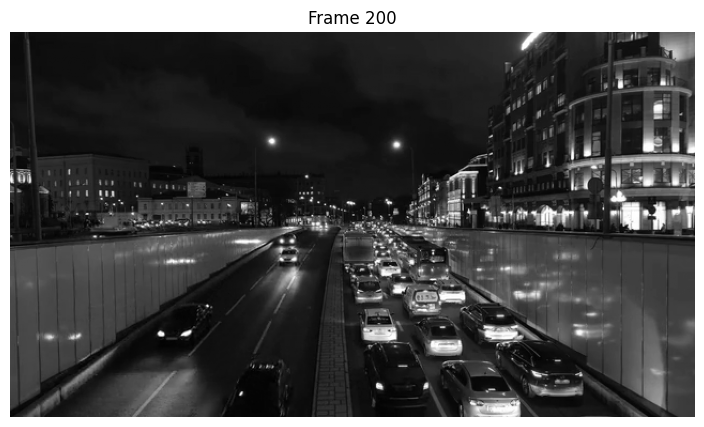

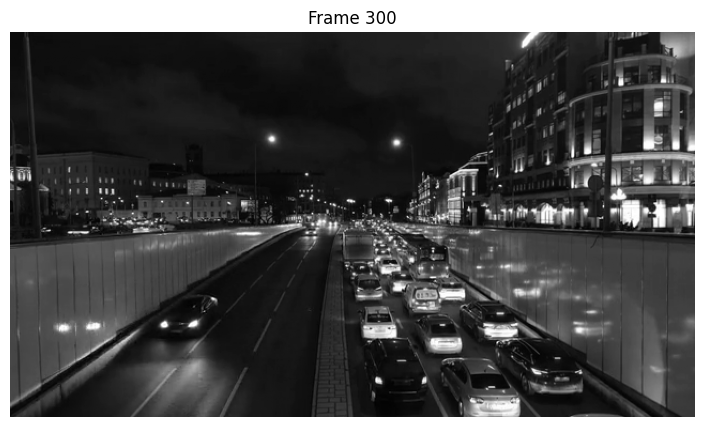

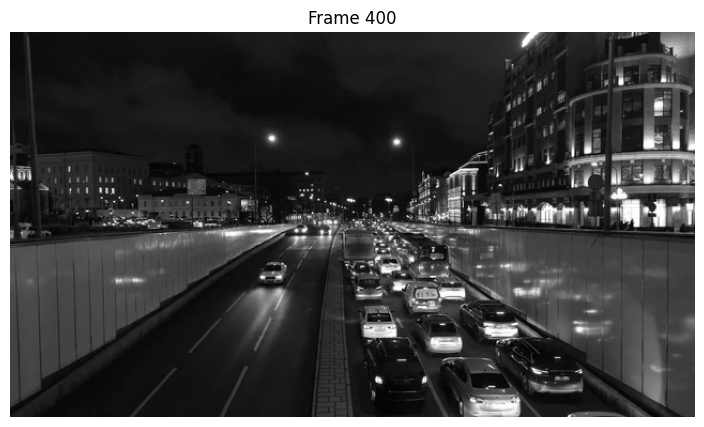

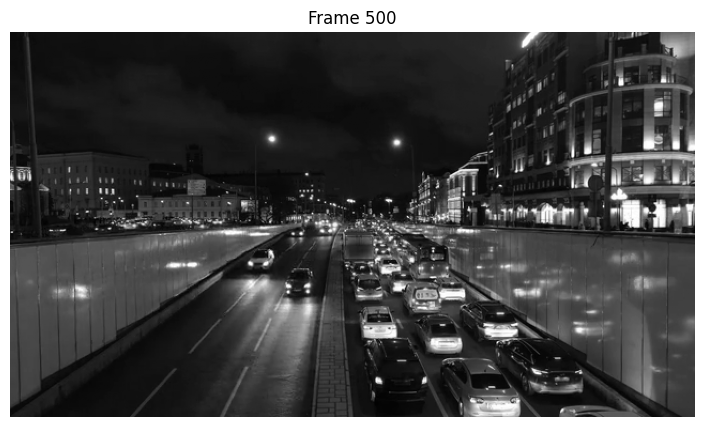

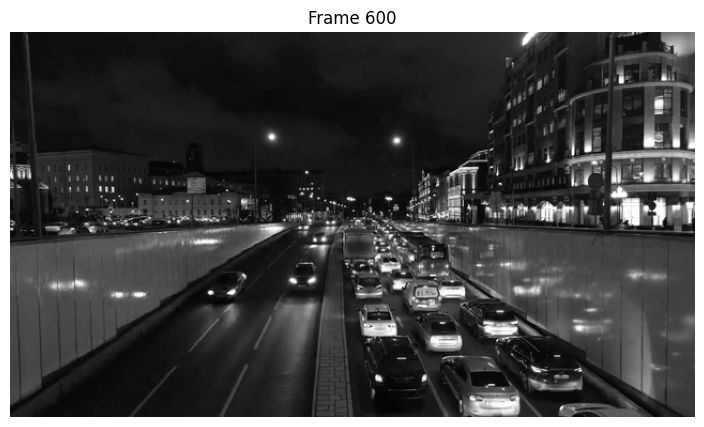

In [8]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)

count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    if count % 100 == 0:

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        plt.figure(figsize=(10,5))

        plt.imshow(gray,cmap="gray")

        plt.title(f"Frame {count}")

        plt.axis("off")

        plt.show()

    count +=1

cap.release()